In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/Users/shiya/Desktop/marketing/bank+marketing/bank/bank-full.csv', sep=';')

# Preview the data
print(df.shape)
df.head()


(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [24]:
# Check for missing values and data info
print(df.isnull().sum())
print("\n")
print(df['y'].value_counts())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


y
no     39922
yes     5289
Name: count, dtype: int64


In [25]:
# Overall conversion rate
total = len(df)
converted = df['y'].value_counts()['yes']
conversion_rate = (converted / total) * 100

print(f"Total contacts: {total}")
print(f"Converted (yes): {converted}")
print(f"Overall conversion rate: {conversion_rate:.2f}%")

Total contacts: 45211
Converted (yes): 5289
Overall conversion rate: 11.70%


     contact  conversion_rate
0   cellular        14.918900
1  telephone        13.420509
2    unknown         4.070661


/var/folders/nf/64ltcbpx5cngh8jrqyw2hm200000gn/T/ipykernel_33897/3203893184.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_conv, x='contact', y='conversion_rate', palette='Blues_d')


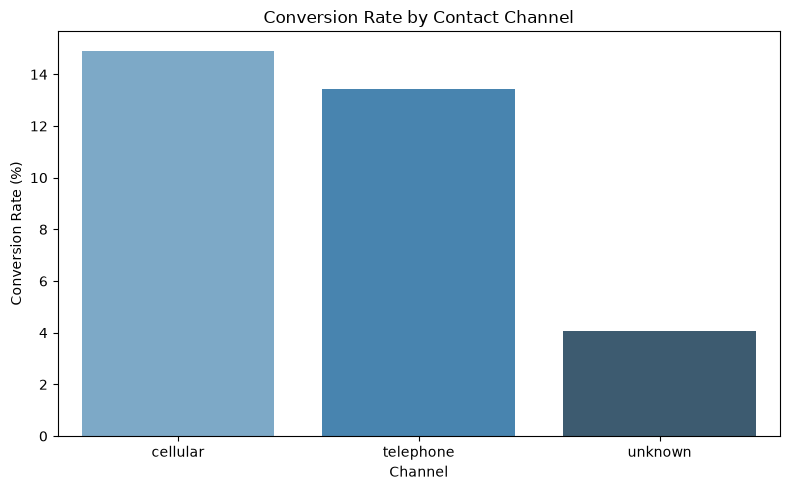

In [26]:
# Conversion rate by contact channel
channel_conv = df.groupby('contact')['y'].apply(lambda x: (x=='yes').sum() / len(x) * 100).reset_index()
channel_conv.columns = ['contact', 'conversion_rate']
print(channel_conv)

# Plot it
plt.figure(figsize=(8,5))
sns.barplot(data=channel_conv, x='contact', y='conversion_rate', palette='Blues_d')
plt.title('Conversion Rate by Contact Channel')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Channel')
plt.tight_layout()
plt.show()

/var/folders/nf/64ltcbpx5cngh8jrqyw2hm200000gn/T/ipykernel_33897/3769570509.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=month_conv, x='month', y='conversion_rate', palette='coolwarm')


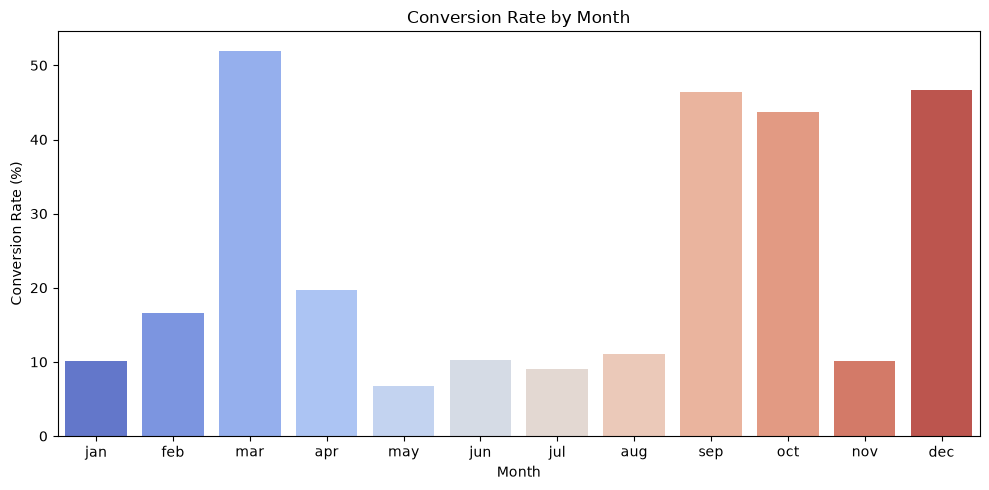

In [27]:
# Conversion rate by month
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_conv = df.groupby('month')['y'].apply(lambda x: (x=='yes').sum() / len(x) * 100).reindex(month_order).reset_index()
month_conv.columns = ['month', 'conversion_rate']

plt.figure(figsize=(10,5))
sns.barplot(data=month_conv, x='month', y='conversion_rate', palette='coolwarm')
plt.title('Conversion Rate by Month')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

/var/folders/nf/64ltcbpx5cngh8jrqyw2hm200000gn/T/ipykernel_33897/2524365553.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=job_conv, x='job', y='conversion_rate', palette='viridis')


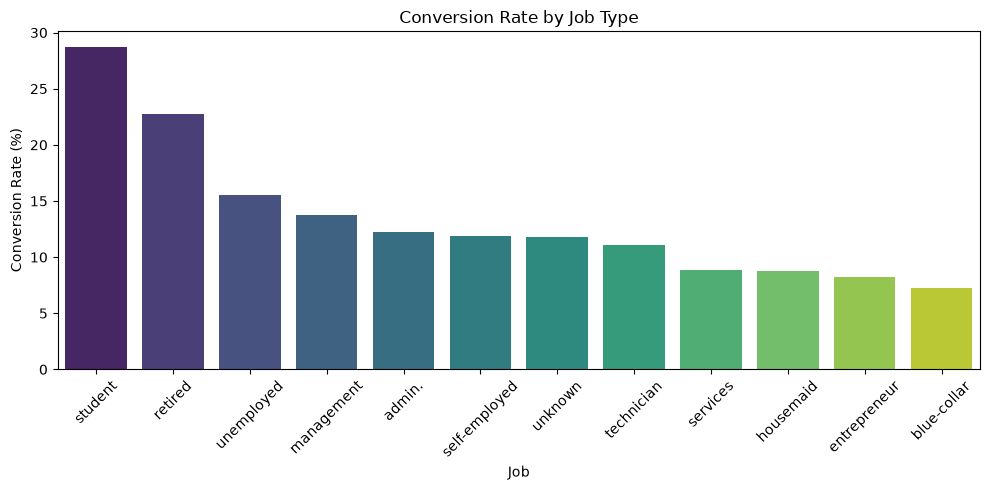

In [28]:
# Conversion rate by job
job_conv = df.groupby('job')['y'].apply(lambda x: (x=='yes').sum() / len(x) * 100).sort_values(ascending=False).reset_index()
job_conv.columns = ['job', 'conversion_rate']

plt.figure(figsize=(10,5))
sns.barplot(data=job_conv, x='job', y='conversion_rate', palette='viridis')
plt.title('Conversion Rate by Job Type')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Job')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

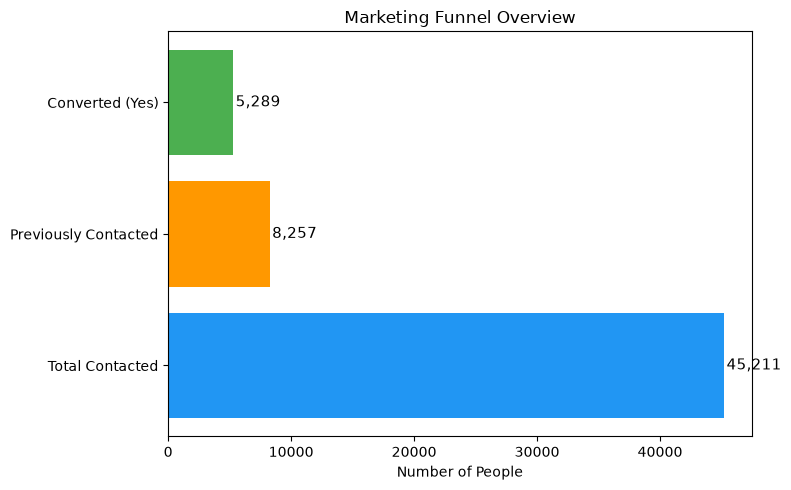

In [29]:
# Funnel visualization
stages = ['Total Contacted', 'Previously Contacted', 'Converted (Yes)']
values = [
    len(df),
    len(df[df['previous'] > 0]),
    len(df[df['y'] == 'yes'])
]

plt.figure(figsize=(8,5))
colors = ['#2196F3', '#FF9800', '#4CAF50']
bars = plt.barh(stages, values, color=colors)
plt.xlabel('Number of People')
plt.title('Marketing Funnel Overview')
for bar, val in zip(bars, values):
    plt.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2, 
             f'{val:,}', va='center', fontsize=11)
plt.tight_layout()
plt.show()

# Marketing Funnel & Conversion Performance Analysis
### Bank Marketing Campaign Dataset (UCI Machine Learning Repository)
**By Ramsia Sidhik | Future Interns Data Science & Analytics — Task 3 (2026)**

---

## Objective
Analyze a bank marketing campaign dataset to understand funnel drop-offs, 
conversion rates, and channel performance — and provide actionable recommendations.

## Dataset
- **Source:** UCI Machine Learning Repository
- **Size:** 45,211 records | 17 features
- **Target variable:** `y` — whether the client subscribed (yes/no)

## Key Findings

| Metric | Value |
|---|---|
| Total Contacts | 45,211 |
| Total Conversions | 5,289 |
| Overall Conversion Rate | 11.70% |
| Best Channel | Cellular (14.9%) |
| Best Month | March (51%) |
| Best Job Segment | Students (29%) |

---

## Insights & Drop-off Analysis

1. **Funnel Drop-off:** Out of 45,211 people contacted, only 5,289 converted — an 88.3% drop-off rate indicating significant room for improvement.

2. **Channel Performance:** Cellular outperforms telephone and unknown channels. Contacts with unknown channel type convert at only 4% — these leads are low quality.

3. **Seasonality:** March, September, October and December show the highest conversion rates (40-51%). May through August are the weakest months with conversion rates below 10%.

4. **Job Segments:** Students (29%) and retired individuals (23%) convert at more than double the overall average. Blue-collar workers convert at only 8%.

---

## Recommendations

1. **Prioritize cellular contact** — shift budget away from unknown/telephone channels toward cellular outreach.

2. **Focus campaigns in March and Q4** — these months yield 3-5x higher conversion rates than summer months.

3. **Target students and retired segments** — they convert at nearly 3x the rate of blue-collar workers.

4. **Re-engage previously contacted leads** — 8,257 people were previously contacted, showing re-engagement potential.

5. **Reduce summer campaign spend** — May to August consistently underperform; reallocate that budget to high-performing months.

---

## Tools Used
- Python (pandas, matplotlib, seaborn)
- Jupyter Notebook in VS Code
- Dataset: Bank Marketing Campaign (UCI)